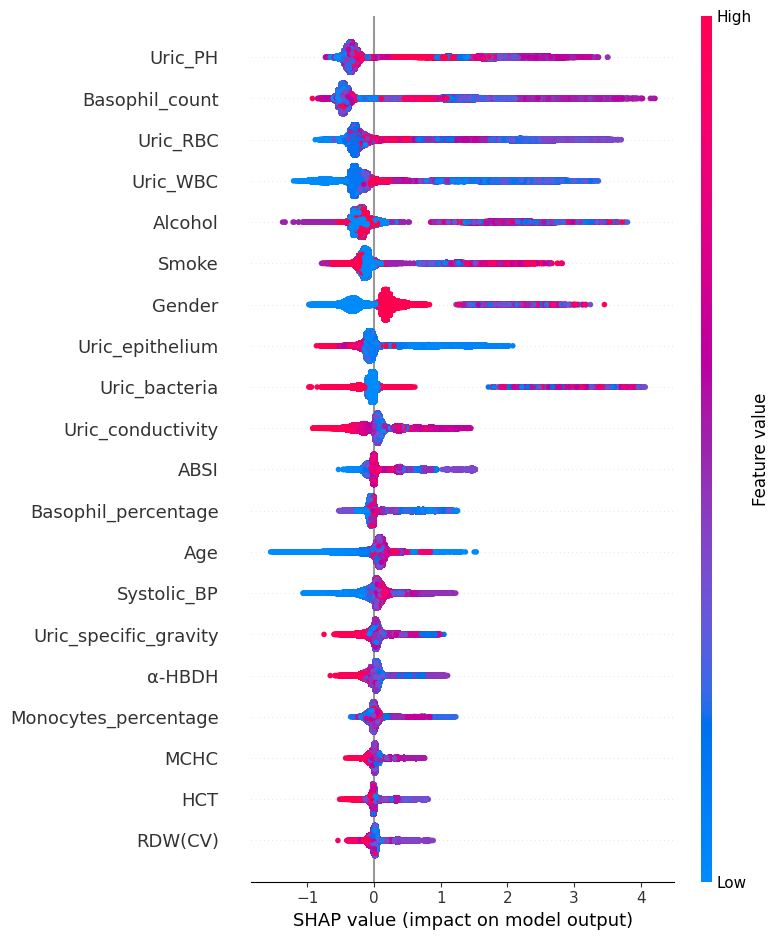

In [3]:
import xgboost as xgb
import shap
import utils
import pandas as pd
import pickle

with open('/home/mclab/ydl/ehr/models/Ver4_mean_mode/model_xgb_05-09_1110_89.21%.pkl', 'rb') as file:
    xgb_model = pickle.load(file)

dataset = '/home/mclab/ydl/ehr/data/Train-test-dataset_Ver4_mean_mode.csv'
df = pd.read_csv(dataset)
X_train, X_test, Y_train, Y_test = utils.get_train_test_data(df)
# 对于原始的 XGBoost Booster 模型
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)


In [5]:
shap.initjs()
# 选择一个样本，例如索引为 0 的样本
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train.iloc[0,:])

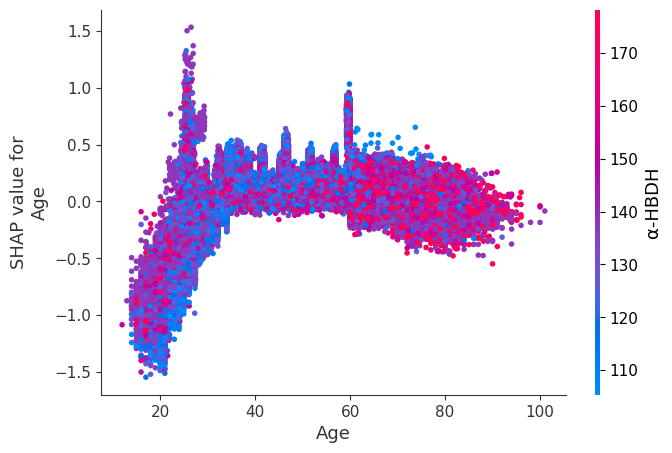

In [6]:
# 例如，查看 'Age' 特征的影响
shap.dependence_plot("Age", shap_values, X_train)

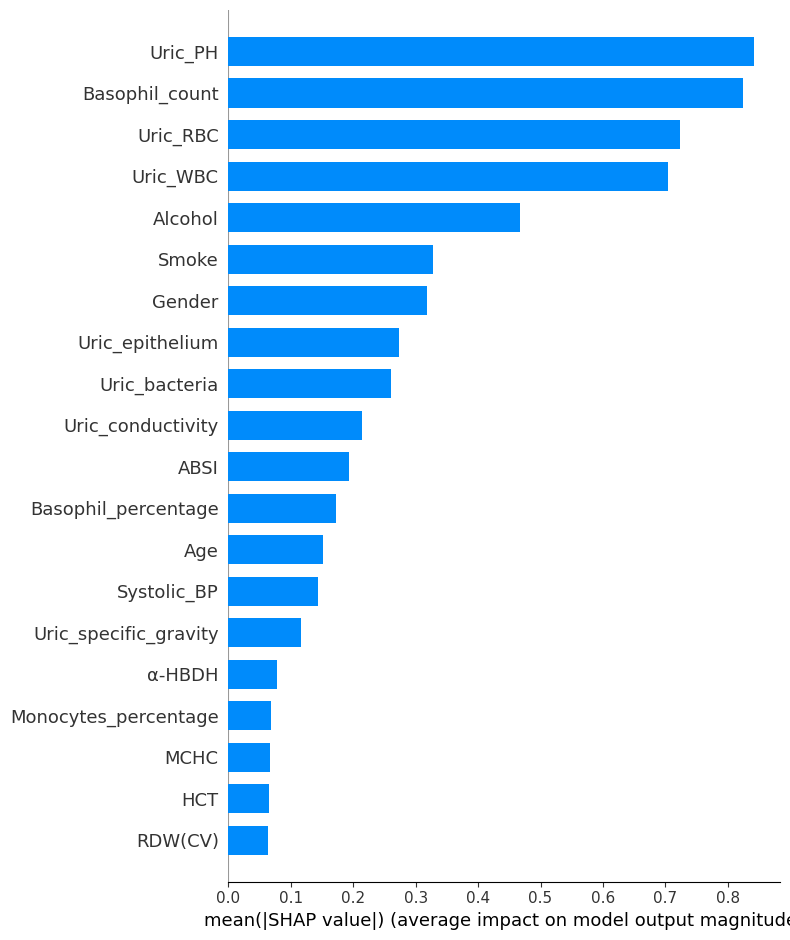

In [7]:
shap.summary_plot(shap_values, X_train, plot_type="bar")